Epoch 1/5


2026-05-04 20:26:07.959730: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - kl_loss: 3.7701 - reconstruction_loss: 174.3994 - total_loss: 178.1695
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - kl_loss: 3.0022 - reconstruction_loss: 169.2143 - total_loss: 172.2165
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 3.1714 - reconstruction_loss: 164.3721 - total_loss: 167.5435
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 3.2175 - reconstruction_loss: 159.4938 - total_loss: 162.7113
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 3.2606 - reconstruction_loss: 155.9093 - total_loss: 159.1699
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


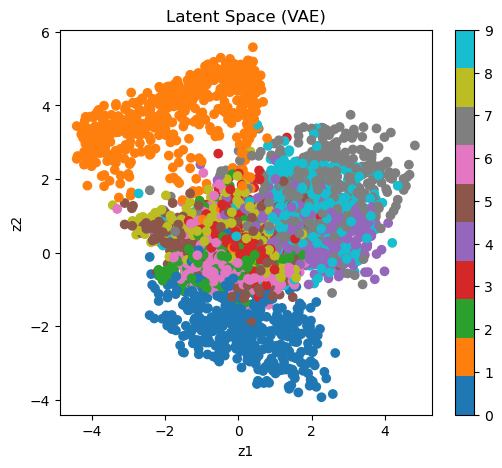

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# Load data
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_train = x_train.reshape(-1, 784)

latent_dim = 2

# -----------------------------
# Encoder
# -----------------------------
inputs = layers.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(inputs)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = tf.keras.Model(inputs, [z_mean, z_log_var, z])

# -----------------------------
# Decoder
# -----------------------------
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
outputs = layers.Dense(784, activation="sigmoid")(x)
decoder = tf.keras.Model(latent_inputs, outputs)

# -----------------------------
# VAE with proper loss tracking
# -----------------------------
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data, reconstruction)
            ) * 784

            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "total_loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

# Train
vae.fit(x_train, epochs=5, batch_size=128)

# -----------------------------
# Latent space visualization
# -----------------------------
z_mean, _, _ = encoder.predict(x_train[:5000])

plt.figure(figsize=(6,5))
plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_train[:5000], cmap="tab10")
plt.colorbar()
plt.title("Latent Space (VAE)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()